# 03 — Evaluation & Results

Loads trained models, runs them on the test period (Dec 2025), and computes:
- Cumulative return
- Sharpe ratio
- Maximum drawdown
- Turnover (number of trades)

Compared against:
- **Buy-and-hold** (single ticker)
- **Equal-weight buy-and-hold** (all 3 tickers)
- **Momentum baseline** (buy if last 5-day return > 0, else hold)

In [1]:
import sys
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from pathlib import Path

PROJECT_ROOT = Path('..').resolve()
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

from trading_env import TradingEnv, make_envs
from stable_baselines3 import PPO, DQN

DATA_DIR    = PROJECT_ROOT / 'data'
MODELS_DIR  = PROJECT_ROOT / 'models'
RESULTS_DIR = PROJECT_ROOT / 'results'
RESULTS_DIR.mkdir(exist_ok=True)

TICKERS      = ['NVDA', 'GOOG', 'TSLA']
TRAIN_CUTOFF = '2025-11-30'
INITIAL_CASH = 10_000.0

daily = pd.read_csv(DATA_DIR / 'daily_features.csv', parse_dates=['date'])
print('Dataset loaded:', daily.shape)

Dataset loaded: (192, 33)


## 1. Metrics Helper Functions

In [2]:
def sharpe_ratio(returns, risk_free=0.0, periods_per_year=252):
    """Annualized Sharpe ratio from a series of period returns."""
    excess = returns - risk_free / periods_per_year
    if excess.std() < 1e-8:
        return 0.0
    return float(excess.mean() / excess.std() * np.sqrt(periods_per_year))

def max_drawdown(portfolio_values):
    """Maximum peak-to-trough drawdown."""
    vals = np.array(portfolio_values)
    peak = np.maximum.accumulate(vals)
    drawdown = (vals - peak) / peak
    return float(drawdown.min())

def cumulative_return(portfolio_values):
    return float((portfolio_values[-1] - portfolio_values[0]) / portfolio_values[0])

def compute_metrics(history_df):
    pv = history_df['portfolio_value'].values
    daily_returns = np.diff(pv) / pv[:-1]
    trades = (history_df['action'] != 1).sum()  # non-hold actions
    return {
        'cumulative_return': cumulative_return(pv),
        'sharpe_ratio':      sharpe_ratio(pd.Series(daily_returns)),
        'max_drawdown':      max_drawdown(pv),
        'turnover':          int(trades),
        'final_value':       float(pv[-1]),
    }

print('Metrics helpers ready.')

Metrics helpers ready.


## 2. Evaluate RL Agents

In [3]:
def run_agent(model, env):
    obs, _ = env.reset()
    done = False
    while not done:
        action, _ = model.predict(obs, deterministic=True)
        obs, _, done, _, _ = env.step(action)
    return env.get_history()

ALGO_CLASSES = {'PPO': PPO, 'DQN': DQN}
STATE_TYPES = ['price', 'sentiment_basic']
ENV_KWARGS = dict(
    reward_mode='log_return',
    drawdown_penalty=0.0,
    volatility_penalty=0.0,
)

all_results = []
histories   = {}  # (ticker, algo, state_type) -> history_df

for ticker in TICKERS:
    envs = make_envs(daily, ticker, TRAIN_CUTOFF, env_kwargs=ENV_KWARGS)

    for algo_name in ['PPO', 'DQN']:
        for state_type in STATE_TYPES:
            model_path = MODELS_DIR / f'{ticker}_{algo_name}_{state_type}.zip'
            if not model_path.exists():
                print(f'  MISSING: {model_path.name} — run notebook 02 first')
                continue

            AlgoClass = ALGO_CLASSES[algo_name]
            model = AlgoClass.load(str(model_path))

            test_env = envs[f'test_{state_type}']
            history = run_agent(model, test_env)
            metrics = compute_metrics(history)

            key = (ticker, algo_name, state_type)
            histories[key] = history
            all_results.append({
                'ticker': ticker, 'algo': algo_name, 'state': state_type, **metrics
            })

results_df = pd.DataFrame(all_results)
print('RL evaluation done.')
results_df


RL evaluation done.


,ticker,algo,state,cumulative_return,sharpe_ratio,max_drawdown,turnover,final_value
0,NVDA,PPO,price,-0.011944,-1.298971,-0.037017,19,9880.557726
1,NVDA,PPO,sentiment_basic,0.008478,0.904390,-0.028020,14,10121.815509
2,NVDA,DQN,price,0.025872,2.430195,-0.028020,15,10296.391470
3,NVDA,DQN,sentiment_basic,0.038077,5.347955,-0.005514,14,10418.892598
4,GOOG,PPO,price,0.009216,1.370707,-0.025785,21,10101.014559
5,GOOG,PPO,sentiment_basic,0.007151,1.098512,-0.025666,21,10080.344819
6,GOOG,DQN,price,-0.018678,-2.460467,-0.028970,12,9813.221600
7,GOOG,DQN,sentiment_basic,0.001668,0.262772,-0.034287,11,10016.683667
8,TSLA,PPO,price,0.056044,4.093858,-0.023421,14,10544.984177
9,TSLA,PPO,sentiment_basic,0.045363,4.322818,-0.016518,21,10438.334362


In [4]:
print('=== Sentiment Uplift: Basic vs Price ===')
delta_rows = []
for ticker in TICKERS:
    sub = results_df[results_df['ticker'] == ticker]
    for algo in ['PPO', 'DQN']:
        price = sub[(sub['algo'] == algo) & (sub['state'] == 'price')]
        basic = sub[(sub['algo'] == algo) & (sub['state'] == 'sentiment_basic')]
        if len(price) == 0 or len(basic) == 0:
            continue
        price = price.iloc[0]
        basic = basic.iloc[0]
        delta_rows.append({
            'ticker': ticker,
            'algo': algo,
            'return_uplift_pp': round((basic['cumulative_return'] - price['cumulative_return']) * 100, 3),
            'sharpe_uplift':    round(basic['sharpe_ratio'] - price['sharpe_ratio'], 3),
        })

delta_df = pd.DataFrame(delta_rows)
print(delta_df.to_string(index=False))


=== Sentiment Uplift: Basic vs Price ===
ticker algo  return_uplift_pp  sharpe_uplift
  NVDA  PPO             2.042          2.203
  NVDA  DQN             1.221          2.918
  GOOG  PPO            -0.207         -0.272
  GOOG  DQN             2.035          2.723
  TSLA  PPO            -1.068          0.229
  TSLA  DQN            -5.207         -7.169


## 3. Compute Baselines

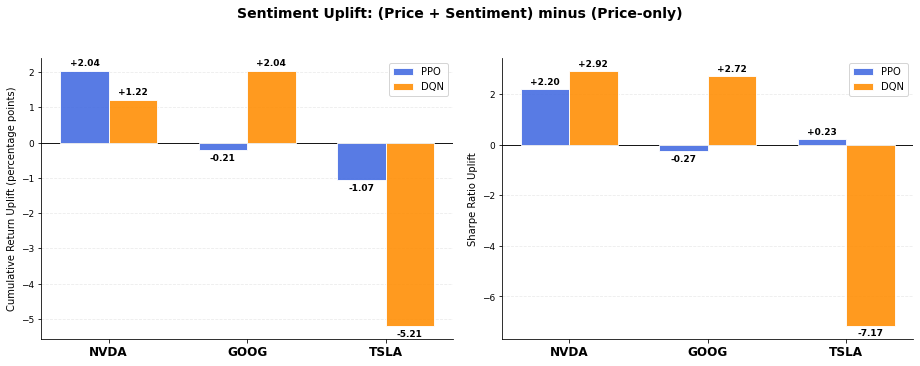

Saved results/sentiment_uplift.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), facecolor='white')
fig.suptitle('Sentiment Uplift: (Price + Sentiment) minus (Price-only)',
             fontsize=14, fontweight='bold', y=1.02)

metrics = [
    ('return_uplift_pp', 'Cumulative Return Uplift (percentage points)'),
    ('sharpe_uplift',    'Sharpe Ratio Uplift'),
]
algo_colors = {'PPO': 'royalblue', 'DQN': 'darkorange'}
bar_width = 0.35
x = np.arange(len(TICKERS))

for ax, (metric, ylabel) in zip(axes, metrics):
    ax.set_facecolor('white')
    ax.grid(axis='y', alpha=0.25, linestyle='--', zorder=0)

    for i, algo in enumerate(['PPO', 'DQN']):
        sub = delta_df[delta_df['algo'] == algo]
        vals = [sub[sub['ticker'] == t][metric].values[0]
                if len(sub[sub['ticker'] == t]) > 0 else 0
                for t in TICKERS]

        offset = (i - 0.5) * bar_width
        bars = ax.bar(x + offset, vals, width=bar_width,
                      label=algo, color=algo_colors[algo],
                      alpha=0.88, zorder=3, edgecolor='white')

        for bar, v in zip(bars, vals):
            va  = 'bottom' if v >= 0 else 'top'
            pad = 0.04 * (ax.get_ylim()[1] - ax.get_ylim()[0]) if ax.get_ylim()[1] != ax.get_ylim()[0] else 0.1
            ax.text(bar.get_x() + bar.get_width() / 2,
                    v + (0.1 if v >= 0 else -0.1),
                    f'{v:+.2f}', ha='center',
                    va=va, fontsize=9, fontweight='bold')

    ax.axhline(0, color='black', linewidth=0.9)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_xticks(x)
    ax.set_xticklabels(TICKERS, fontsize=12, fontweight='bold')
    ax.tick_params(axis='y', labelsize=9)

    legend = ax.legend(fontsize=10, framealpha=0.95,
                       edgecolor='lightgray', facecolor='white',
                       loc='upper right')

    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

plt.tight_layout(pad=1.5)
plt.savefig(RESULTS_DIR / 'sentiment_uplift.png', dpi=200, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()
print('Saved results/sentiment_uplift.png')


In [6]:
baseline_results = []
baseline_histories = {}

def buy_and_hold(test_df, initial_cash=INITIAL_CASH):
    """Buy as many shares as possible on day 0, hold until end."""
    prices = test_df['close'].values
    shares = int(initial_cash // prices[0])
    cash = initial_cash - shares * prices[0]
    portfolio = cash + shares * prices
    daily_ret = np.diff(portfolio) / portfolio[:-1]
    actions = np.ones(len(prices), dtype=int)  # all hold
    actions[0] = 2  # buy
    return pd.DataFrame({
        'portfolio_value': portfolio,
        'action': actions,
    }), portfolio

def momentum_baseline(test_df, initial_cash=INITIAL_CASH, window=5):
    """Buy when 5-day return is positive, sell otherwise."""
    prices = test_df['close'].values
    cash = initial_cash
    position = 0
    portfolio = []
    actions = []
    for i in range(len(prices)):
        pv = cash + position * prices[i]
        portfolio.append(pv)
        if i >= window:
            momentum = prices[i] / prices[i - window] - 1
            if momentum > 0 and position == 0 and cash >= prices[i]:
                position += 1
                cash -= prices[i]
                actions.append(2)
            elif momentum <= 0 and position > 0:
                cash += position * prices[i]
                position = 0
                actions.append(0)
            else:
                actions.append(1)
        else:
            actions.append(1)
    return pd.DataFrame({'portfolio_value': portfolio, 'action': actions}), np.array(portfolio)

for ticker in TICKERS:
    test_df = daily[(daily['ticker'] == ticker) & (daily['date'] > TRAIN_CUTOFF)].copy()
    if len(test_df) == 0:
        continue

    for baseline_name, fn in [('buy_and_hold', buy_and_hold), ('momentum', momentum_baseline)]:
        hist, pv = fn(test_df)
        metrics = compute_metrics(hist)
        baseline_histories[(ticker, baseline_name)] = hist
        baseline_results.append({
            'ticker': ticker, 'algo': baseline_name, 'state': 'baseline', **metrics
        })

# Equal-weight buy-and-hold across all 3 tickers
eq_cash = INITIAL_CASH / 3
eq_portfolios = []
for ticker in TICKERS:
    test_df = daily[(daily['ticker'] == ticker) & (daily['date'] > TRAIN_CUTOFF)].copy()
    _, pv = buy_and_hold(test_df, initial_cash=eq_cash)
    # Align lengths
    eq_portfolios.append(pv)

min_len = min(len(p) for p in eq_portfolios)
eq_total = sum(p[:min_len] for p in eq_portfolios)
eq_actions = np.ones(min_len, dtype=int)
eq_actions[0] = 2
eq_hist = pd.DataFrame({'portfolio_value': eq_total, 'action': eq_actions})
eq_metrics = compute_metrics(eq_hist)
baseline_results.append({'ticker': 'ALL', 'algo': 'equal_weight_bh', 'state': 'baseline', **eq_metrics})

baselines_df = pd.DataFrame(baseline_results)
print('Baselines computed.')
baselines_df

Baselines computed.


,ticker,algo,state,cumulative_return,sharpe_ratio,max_drawdown,turnover,final_value
0,NVDA,buy_and_hold,baseline,0.036190,1.580470,-0.077942,1,10361.900101
1,NVDA,momentum,baseline,0.000089,0.394521,-0.000462,4,10000.889984
2,GOOG,buy_and_hold,baseline,-0.004092,-0.130587,-0.072917,1,9959.079773
3,GOOG,momentum,baseline,-0.000158,-0.581091,-0.000730,4,9998.420013
4,TSLA,buy_and_hold,baseline,0.045034,1.569225,-0.081210,1,10450.339691
5,TSLA,momentum,baseline,0.002370,2.084134,-0.002253,6,10023.700043
6,ALL,equal_weight_bh,baseline,0.024230,1.435060,-0.036593,1,10242.299866


## 4. Results Table

In [7]:
combined = pd.concat([results_df, baselines_df], ignore_index=True)

fmt = combined.copy()
fmt['cumulative_return'] = (fmt['cumulative_return'] * 100).round(2).astype(str) + '%'
fmt['sharpe_ratio']      = fmt['sharpe_ratio'].round(3)
fmt['max_drawdown']      = (fmt['max_drawdown'] * 100).round(2).astype(str) + '%'
fmt['final_value']       = '$' + fmt['final_value'].round(2).astype(str)

display_cols = ['ticker', 'algo', 'state', 'cumulative_return', 'sharpe_ratio', 'max_drawdown', 'turnover', 'final_value']
print('\n=== FULL RESULTS TABLE ===')
print(fmt[display_cols].to_string(index=False))

combined.to_csv(RESULTS_DIR / 'results.csv', index=False)
print('\nSaved to results/results.csv')


=== FULL RESULTS TABLE ===
ticker            algo           state cumulative_return  sharpe_ratio max_drawdown  turnover final_value
  NVDA             PPO           price            -1.19%        -1.299        -3.7%        19    $9880.56
  NVDA             PPO sentiment_basic             0.85%         0.904        -2.8%        14   $10121.82
  NVDA             DQN           price             2.59%         2.430        -2.8%        15   $10296.39
  NVDA             DQN sentiment_basic             3.81%         5.348       -0.55%        14   $10418.89
  GOOG             PPO           price             0.92%         1.371       -2.58%        21   $10101.01
  GOOG             PPO sentiment_basic             0.72%         1.099       -2.57%        21   $10080.34
  GOOG             DQN           price            -1.87%        -2.460        -2.9%        12    $9813.22
  GOOG             DQN sentiment_basic             0.17%         0.263       -3.43%        11   $10016.68
  TSLA            

## 5. Price vs Sentiment Comparison

In [8]:
print('=== Feature Ablation: Price vs Basic Sentiment ===')
print()

for ticker in TICKERS:
    print(f'--- {ticker} ---')
    sub = results_df[results_df['ticker'] == ticker]
    for algo in ['PPO', 'DQN']:
        basic = sub[(sub['algo'] == algo) & (sub['state'] == 'sentiment_basic')]
        price = sub[(sub['algo'] == algo) & (sub['state'] == 'price')]
        if len(basic) == 0 or len(price) == 0:
            continue
        basic, price = basic.iloc[0], price.iloc[0]
        ret_delta = basic['cumulative_return'] - price['cumulative_return']
        sharpe_delta = basic['sharpe_ratio'] - price['sharpe_ratio']
        print(f'  {algo} | sentiment_basic vs price: return {ret_delta*100:+.2f}pp | sharpe {sharpe_delta:+.3f}')
    print()


=== Feature Ablation: Price vs Basic Sentiment ===

--- NVDA ---
  PPO | sentiment_basic vs price: return +2.04pp | sharpe +2.203
  DQN | sentiment_basic vs price: return +1.22pp | sharpe +2.918

--- GOOG ---
  PPO | sentiment_basic vs price: return -0.21pp | sharpe -0.272
  DQN | sentiment_basic vs price: return +2.03pp | sharpe +2.723

--- TSLA ---
  PPO | sentiment_basic vs price: return -1.07pp | sharpe +0.229
  DQN | sentiment_basic vs price: return -5.21pp | sharpe -7.169



## 6. Portfolio Value Over Time

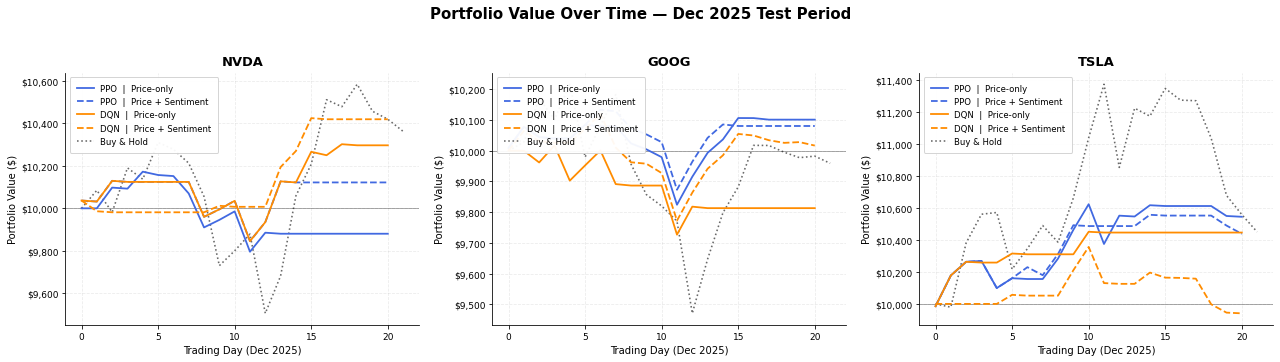

Saved results/portfolio_curves.png


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False, facecolor='white')
fig.suptitle('Portfolio Value Over Time — Dec 2025 Test Period', fontsize=15, fontweight='bold', y=1.01)

styles = {
    ('PPO', 'price'):           ('royalblue',  '-',  1.8, 'PPO  |  Price-only'),
    ('PPO', 'sentiment_basic'): ('royalblue',  '--', 1.8, 'PPO  |  Price + Sentiment'),
    ('DQN', 'price'):           ('darkorange', '-',  1.8, 'DQN  |  Price-only'),
    ('DQN', 'sentiment_basic'): ('darkorange', '--', 1.8, 'DQN  |  Price + Sentiment'),
}

for ax, ticker in zip(axes, TICKERS):
    ax.set_facecolor('white')
    ax.grid(alpha=0.25, linestyle='--', zorder=0)

    for (algo, state), (color, ls, lw, label) in styles.items():
        key = (ticker, algo, state)
        if key in histories:
            ax.plot(histories[key]['portfolio_value'].values,
                    color=color, linestyle=ls, linewidth=lw, label=label, zorder=3)

    bh_key = (ticker, 'buy_and_hold')
    if bh_key in baseline_histories:
        ax.plot(baseline_histories[bh_key]['portfolio_value'].values,
                color='dimgray', linestyle=':', linewidth=1.6, label='Buy & Hold', zorder=2)

    ax.axhline(INITIAL_CASH, color='black', linewidth=0.8, linestyle='-', alpha=0.4)
    ax.set_title(ticker, fontsize=13, fontweight='bold', pad=8)
    ax.set_xlabel('Trading Day (Dec 2025)', fontsize=10)
    ax.set_ylabel('Portfolio Value ($)', fontsize=10)
    ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))
    ax.tick_params(labelsize=9)

    legend = ax.legend(fontsize=8.5, loc='upper left',
                       framealpha=0.95, edgecolor='lightgray',
                       facecolor='white', borderpad=0.8)

for spine in ['top', 'right']:
    for ax in axes:
        ax.spines[spine].set_visible(False)

plt.tight_layout(pad=1.5)
plt.savefig(RESULTS_DIR / 'portfolio_curves.png', dpi=200, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()
print('Saved results/portfolio_curves.png')


## 7. Sharpe Ratio Comparison

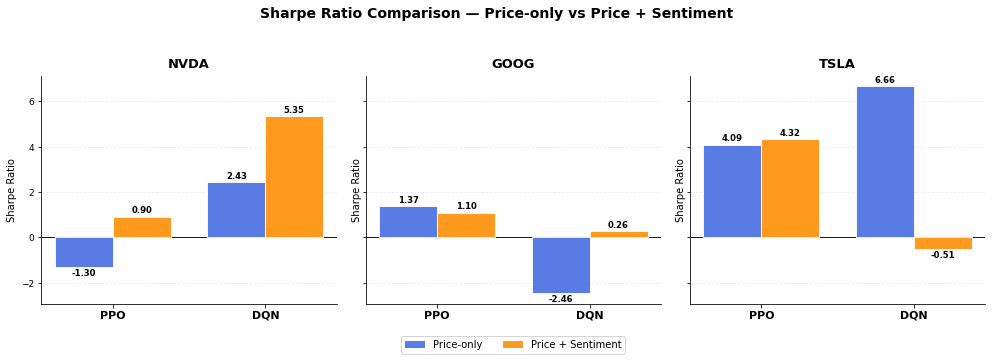

Saved results/sharpe_comparison.png


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=True, facecolor='white')
fig.suptitle('Sharpe Ratio Comparison — Price-only vs Price + Sentiment', fontsize=14, fontweight='bold', y=1.02)

state_palette = {'price': 'royalblue', 'sentiment_basic': 'darkorange'}
state_labels  = {'price': 'Price-only', 'sentiment_basic': 'Price + Sentiment'}

bar_width = 0.38
x = np.arange(2)  # PPO, DQN

for ax, ticker in zip(axes, TICKERS):
    ax.set_facecolor('white')
    ax.grid(axis='y', alpha=0.25, linestyle='--', zorder=0)

    for i, state in enumerate(STATE_TYPES):
        sub = results_df[results_df['ticker'] == ticker]
        vals = []
        for algo in ['PPO', 'DQN']:
            row = sub[(sub['algo'] == algo) & (sub['state'] == state)]
            vals.append(row.iloc[0]['sharpe_ratio'] if len(row) > 0 else 0)

        offset = (i - 0.5) * bar_width
        bars = ax.bar(x + offset, vals, width=bar_width,
                      color=state_palette[state], alpha=0.88,
                      label=state_labels[state], zorder=3, edgecolor='white')

        for bar, v in zip(bars, vals):
            va = 'bottom' if v >= 0 else 'top'
            pad = 0.08 if v >= 0 else -0.08
            ax.text(bar.get_x() + bar.get_width() / 2, v + pad,
                    f'{v:.2f}', ha='center', va=va, fontsize=8.5, fontweight='bold')

    ax.axhline(0, color='black', linewidth=0.9)
    ax.set_title(ticker, fontsize=13, fontweight='bold', pad=8)
    ax.set_ylabel('Sharpe Ratio', fontsize=10)
    ax.set_xticks(x)
    ax.set_xticklabels(['PPO', 'DQN'], fontsize=11, fontweight='bold')
    ax.tick_params(axis='y', labelsize=9)

    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=state_palette[s], label=state_labels[s], alpha=0.88)
                   for s in STATE_TYPES]
axes[1].legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, -0.12),
               ncol=2, fontsize=10, framealpha=0.95, edgecolor='lightgray', facecolor='white')

plt.tight_layout(pad=1.5)
plt.savefig(RESULTS_DIR / 'sharpe_comparison.png', dpi=200, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()
print('Saved results/sharpe_comparison.png')


In [11]:
for ticker in TICKERS:
    test_df = daily[(daily['ticker'] == ticker) & (daily['date'] > TRAIN_CUTOFF)].reset_index(drop=True)
    if len(test_df) == 0:
        continue
    threshold = test_df['article_count'].quantile(0.75)
    high_news_days = (test_df['article_count'] >= threshold)
    print(f'{ticker}: {high_news_days.sum()} high-news days (>= {threshold:.0f} articles), ' 
          f'{(~high_news_days).sum()} low-news days')

    for algo in ['PPO', 'DQN']:
        reward_means = {}
        for state in STATE_TYPES:
            key = (ticker, algo, state)
            if key not in histories:
                continue
            history = histories[key]
            n = min(len(history), len(test_df))
            mask = high_news_days.values[:n]
            rewards = history['reward'].values[:n]
            reward_means[state] = (rewards[mask].mean(), rewards[~mask].mean())

        if reward_means:
            summary = ' | '.join(
                f"{state}: high={vals[0]:.4f}, low={vals[1]:.4f}"
                for state, vals in reward_means.items()
            )
            print(f'  {algo} | {summary}')
    print()


NVDA: 6 high-news days (>= 20 articles), 16 low-news days
  PPO | price: high=-0.0000, low=-0.0009 | sentiment_basic: high=-0.0000, low=0.0006
  DQN | price: high=0.0005, low=0.0014 | sentiment_basic: high=-0.0002, low=0.0024

GOOG: 6 high-news days (>= 30 articles), 16 low-news days
  PPO | price: high=0.0014, low=0.0000 | sentiment_basic: high=-0.0002, low=0.0004
  DQN | price: high=-0.0000, low=-0.0013 | sentiment_basic: high=0.0008, low=-0.0004

TSLA: 6 high-news days (>= 32 articles), 16 low-news days
  PPO | price: high=-0.0016, low=0.0036 | sentiment_basic: high=-0.0025, low=0.0033
  DQN | price: high=-0.0000, low=0.0026 | sentiment_basic: high=-0.0052, low=0.0010

